# TechMind - EDA y evaluación del modelo candidato v4

Análisis exploratorio, entrenamiento y validación del modelo de clasificación de contenidos técnicos.

El dataset fue enriquecido de 98 a 125 registros y quedó balanceado con 25 ejemplos por categoría. La versión v4 se evalúa como candidata y no reemplaza todavía al modelo estable v3.

In [83]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)

## 1. Carga del dataset

Se carga el dataset enriquecido utilizado para entrenar y evaluar el modelo candidato v4.

In [84]:
ruta_dataset = "/content/dataset_techmind_candidato_v4.xlsx"
df = pd.read_excel(ruta_dataset)

## 2. Limpieza y revisión de los datos

Se eliminan las filas sin categoría y se revisa la estructura general del dataset.

In [85]:
df = df.dropna(subset=["categoria"])

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, 0 to 129
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    125 non-null    object
 1   titulo                125 non-null    object
 2   descripcion           125 non-null    object
 3   categoria             125 non-null    object
 4   subtema               125 non-null    object
 5   palabras_clave        125 non-null    object
 6   fuente                125 non-null    object
 7   url                   123 non-null    object
 8   tipo_fuente           125 non-null    object
 9   descripcion_adaptada  125 non-null    object
 10  fecha_recoleccion     125 non-null    object
 11  temas_relacionados    125 non-null    object
 12  resumen_corto         125 non-null    object
dtypes: object(13)
memory usage: 13.7+ KB


## 3. Distribución de categorías

Se verifica la cantidad y el porcentaje de registros por categoría para comprobar el balance del dataset.

In [87]:
frecuencia = df["categoria"].value_counts()
porcentaje = df["categoria"].value_counts(normalize=True) * 100

tabla_frecuencias = pd.DataFrame({
    "Frecuencia": frecuencia,
    "Porcentaje": porcentaje.round(2)
})
tabla_frecuencias

,Frecuencia,Porcentaje
categoria,,
Data Science,25,20.0
Frontend,25,20.0
Cloud/DevOps,25,20.0
Backend,25,20.0
Bases de Datos,25,20.0


In [88]:
tabla_distribucion_estilizada = (
    tabla_frecuencias.style
                     .format({"Porcentaje": "{:.1f}%"})
                     .bar(subset=["Frecuencia"], color="#B7A7E3")
                     .background_gradient(subset=["Porcentaje"], cmap="Purples")
                     .set_caption("Distribución de contenidos por categoría")
)
tabla_distribucion_estilizada

,Frecuencia,Porcentaje
categoria,,
Data Science,25,20.0%
Frontend,25,20.0%
Cloud/DevOps,25,20.0%
Backend,25,20.0%
Bases de Datos,25,20.0%


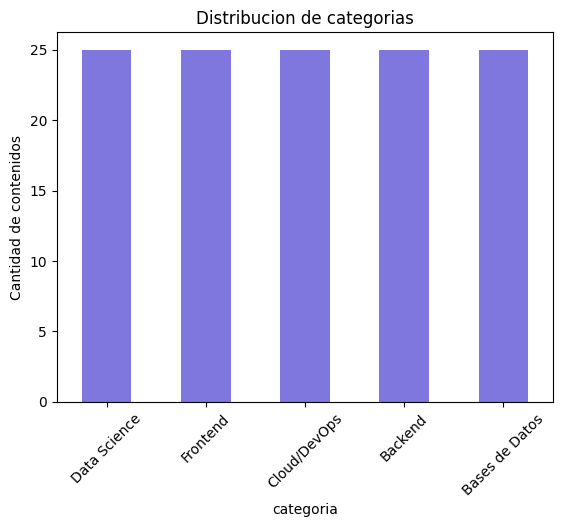

In [89]:
df['categoria'].value_counts().plot(kind='bar', color='#7F77DD')
plt.title("Distribucion de categorias")
plt.ylabel("Cantidad de contenidos")
plt.xticks(rotation=45)
plt.show()

## 4. Preparación del texto

Se normaliza el contenido y se eliminan términos poco informativos para facilitar el análisis exploratorio.

In [90]:
STOPWORDS_ES = {
    "el","la","los","las","de","del","en","un","una","unos","unas","y","o","a",
    "para","por","con","sin","que","como","se","su","sus","es","son","este",
    "esta","estos","estas","al","lo","le","les","mas","muy","entre","sobre",
    "ya","desde","cuando","donde","tambien","antes","despues","usando","uso"
}

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", texto)
    tokens = texto.split()
    tokens = [t for t in tokens if t not in STOPWORDS_ES and len(t) > 2]
    return " ".join(tokens)

In [91]:
df["texto_limpio"] = (
    df["titulo"].fillna("") + " " +
    df["descripcion_adaptada"].fillna("")
).apply(limpiar_texto)

df[["titulo", "texto_limpio"]]

,titulo,texto_limpio
0,Pandas: conociendo la biblioteca,pandas conociendo biblioteca importacion exploracion inicial conjuntos datos...
1,Pandas: seleccionar y agrupar datos,pandas seleccionar agrupar datos filtrado seleccion agrupamiento registros d...
2,Pandas: transformacion y manipulacion de datos,pandas transformacion manipulacion datos creacion transformacion columnas tr...
3,Pandas E/S: trabajando con diferentes formatos de archivo,pandas trabajando diferentes formatos archivo carga exportacion datos format...
4,NumPy: analisis numerico eficiente con Python,numpy analisis numerico eficiente python operaciones arrays vectores numeric...
...,...,...
125,Transacciones y niveles de aislamiento en PostgreSQL,transacciones niveles aislamiento postgresql gestión transacciones sql nivel...
126,Índices GIN para consultar documentos JSONB,índices gin consultar documentos jsonb creación índices gin acelerar consult...
127,"Claves, restricciones y relaciones entre tablas",claves restricciones relaciones tablas modelado relacional claves primarias ...
128,Bloqueos y control de concurrencia en la base de datos,bloqueos control concurrencia base datos bloqueos mvcc coordinar accesos con...


## 5. Análisis de la longitud de los textos

Se compara la extensión de los contenidos entre categorías para identificar diferencias y posibles valores atípicos.

In [92]:
df["longitud_texto"] = df["texto_limpio"].str.len()

df.groupby("categoria")["longitud_texto"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(1)

,count,mean,median,std,min,max
categoria,,,,,,
Backend,25,146.5,144.0,23.5,105,187
Bases de Datos,25,144.6,143.0,32.4,98,216
Cloud/DevOps,25,133.4,130.0,19.1,101,191
Data Science,25,130.7,125.0,25.1,100,181
Frontend,25,139.0,142.0,16.4,110,166


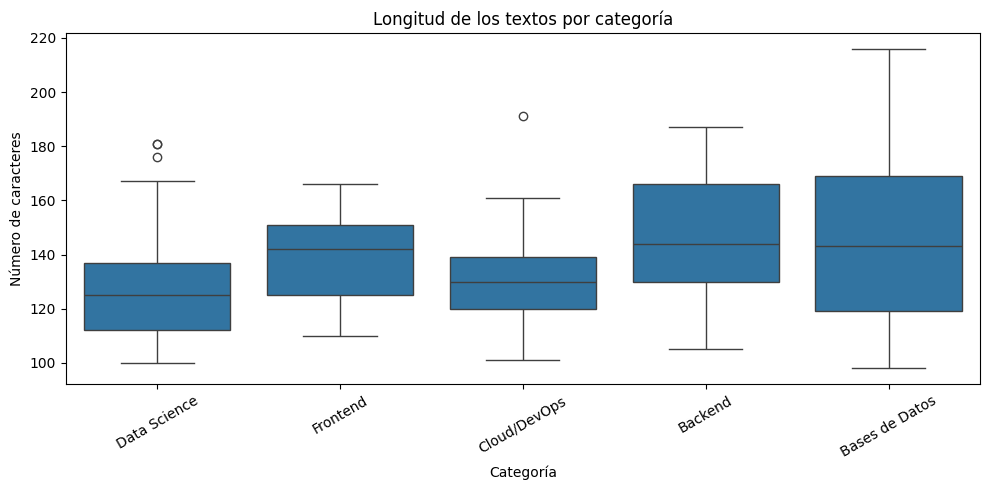

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="categoria", y="longitud_texto", ax=ax)
ax.set_title("Longitud de los textos por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Número de caracteres")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 6. Entrenamiento y evaluación inicial

Se combinan el título, la descripción y las palabras clave. Luego, los datos se dividen en entrenamiento y prueba manteniendo la proporción de las cinco categorías.

El texto se representa mediante TF-IDF y se entrena una regresión logística.

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

df["texto_modelo"] = (
    df["titulo"].fillna("").astype(str) + " " +
    df["descripcion_adaptada"].fillna("").astype(str) + " " +
    df["palabras_clave"].fillna("").astype(str)
)

df["texto_modelo"] = (
    df["texto_modelo"]
    .str.replace(";", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

X_train, X_test, y_train, y_test = train_test_split(
    df["texto_modelo"],
    df["categoria"],
    test_size=0.20,
    random_state=42,
    stratify=df["categoria"]
)

vectorizador = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizador.fit_transform(X_train)
X_test_tfidf = vectorizador.transform(X_test)

modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo.fit(X_train_tfidf, y_train)
predicciones_modelo = modelo.predict(X_test_tfidf)

accuracy_modelo = accuracy_score(y_test, predicciones_modelo)
f1_modelo = f1_score(y_test, predicciones_modelo, average="macro")

print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))
print("Accuracy:", round(accuracy_modelo, 4))
print("F1 macro:", round(f1_modelo, 4))

Registros de entrenamiento: 100
Registros de prueba: 25
Accuracy: 0.88
F1 macro: 0.8816


## 7. Validación cruzada del candidato v4

Se utiliza validación cruzada estratificada de cinco particiones para comprobar que el resultado no dependa de una sola división de los datos.

In [95]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

pipeline_candidato = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv_candidato = cross_validate(
    pipeline_candidato,
    df["texto_modelo"],
    df["categoria"],
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro"
    }
)

accuracy_media = resultados_cv_candidato["test_accuracy"].mean()
accuracy_std = resultados_cv_candidato["test_accuracy"].std()
f1_media = resultados_cv_candidato["test_f1_macro"].mean()
f1_std = resultados_cv_candidato["test_f1_macro"].std()

print("Accuracy por fold:")
print(resultados_cv_candidato["test_accuracy"])

print("\nF1 macro por fold:")
print(resultados_cv_candidato["test_f1_macro"])

print("\nAccuracy promedio:", round(accuracy_media, 4))
print("Desviación accuracy:", round(accuracy_std, 4))
print("F1 macro promedio:", round(f1_media, 4))
print("Desviación F1:", round(f1_std, 4))

Accuracy por fold:
[0.84 0.92 0.92 0.92 0.84]

F1 macro por fold:
[0.83777778 0.91363636 0.91363636 0.91919192 0.82772783]

Accuracy promedio: 0.888
Desviación accuracy: 0.0392
F1 macro promedio: 0.8824
Desviación F1: 0.0407


## 8. Comparación contra un modelo Dummy

El modelo Dummy funciona como referencia mínima. Siempre predice la categoría más frecuente y permite comprobar que el candidato aprende patrones reales del texto.

In [96]:
from sklearn.dummy import DummyClassifier

pipeline_dummy = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "dummy",
        DummyClassifier(
            strategy="most_frequent",
            random_state=42
        )
    )
])

resultados_dummy = cross_validate(
    pipeline_dummy,
    df["texto_modelo"],
    df["categoria"],
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro"
    }
)

print("Dummy accuracy por fold:")
print(resultados_dummy["test_accuracy"])

print("\nDummy F1 macro por fold:")
print(resultados_dummy["test_f1_macro"])

print("\nDummy accuracy promedio:",
      round(resultados_dummy["test_accuracy"].mean(), 4))

print("Dummy F1 macro promedio:",
      round(resultados_dummy["test_f1_macro"].mean(), 4))

print("\nMejora del candidato sobre Dummy:")
print("Accuracy:",
      round(accuracy_media - resultados_dummy["test_accuracy"].mean(), 4))

print("F1 macro:",
      round(f1_media - resultados_dummy["test_f1_macro"].mean(), 4))

Dummy accuracy por fold:
[0.2 0.2 0.2 0.2 0.2]

Dummy F1 macro por fold:
[0.06666667 0.06666667 0.06666667 0.06666667 0.06666667]

Dummy accuracy promedio: 0.2
Dummy F1 macro promedio: 0.0667

Mejora del candidato sobre Dummy:
Accuracy: 0.688
F1 macro: 0.8157


## 9. Entrenamiento y guardado del candidato

Después de la evaluación, el pipeline se entrena con los 125 registros y se guarda como modelo candidato v4. También se recarga para comprobar que el archivo funciona correctamente.

In [97]:
import joblib
import sklearn

modelo_v4_candidato = pipeline_candidato.fit(
    df["texto_modelo"],
    df["categoria"]
)

ruta_modelo_v4 = "modelo_techmind_v4_candidato.joblib"

joblib.dump(
    modelo_v4_candidato,
    ruta_modelo_v4
)

print("Modelo guardado:", ruta_modelo_v4)
print("Registros utilizados:", len(df))
print("Versión de scikit-learn:", sklearn.__version__)
print("Categorías:")
print(modelo_v4_candidato.named_steps["modelo"].classes_)

Modelo guardado: modelo_techmind_v4_candidato.joblib
Registros utilizados: 125
Versión de scikit-learn: 1.6.1
Categorías:
['Backend' 'Bases de Datos' 'Cloud/DevOps' 'Data Science' 'Frontend']


In [98]:
modelo_v4_verificado = joblib.load(
    "modelo_techmind_v4_candidato.joblib"
)

print("Modelo recargado correctamente")
print(
    modelo_v4_verificado.predict([
        "Arquitectura backend con microservicios, patrón Saga y Outbox para coordinar eventos"
    ])
)

Modelo recargado correctamente
['Backend']


In [99]:
print("Registros totales:", len(df))

print("\nDistribución:")
print(df["categoria"].value_counts().sort_index())

print("\nResultados del conjunto de prueba:")
print("Accuracy:", round(accuracy_modelo, 4))
print("F1 macro:", round(f1_modelo, 4))

print("\nValidación cruzada:")
print("Accuracy promedio:", round(accuracy_media, 4))
print("Desviación accuracy:", round(accuracy_std, 4))
print("F1 macro promedio:", round(f1_media, 4))
print("Desviación F1:", round(f1_std, 4))

Registros totales: 125

Distribución:
categoria
Backend           25
Bases de Datos    25
Cloud/DevOps      25
Data Science      25
Frontend          25
Name: count, dtype: int64

Resultados del conjunto de prueba:
Accuracy: 0.88
F1 macro: 0.8816

Validación cruzada:
Accuracy promedio: 0.888
Desviación accuracy: 0.0392
F1 macro promedio: 0.8824
Desviación F1: 0.0407


## 10. Validación con casos externos

Se conservan seis casos definidos antes del enriquecimiento. Estas pruebas no forman parte del entrenamiento y permiten evaluar el comportamiento del candidato ante ejemplos reales.

In [100]:
pruebas_externas = [
    {
        "prueba": 1,
        "titulo": "Arquitectura de microservicios",
        "texto": """Arquitectura de microservicios y gestión de datos transaccionales

El desarrollo de sistemas distribuidos modernos requiere patrones para mantener la consistencia de los datos entre diferentes bases de datos independientes. Cuando una operación involucra múltiples servicios, las transacciones ACID tradicionales no se pueden aplicar de forma directa. En su lugar, se utilizan patrones como Sagas para gestionar transacciones distribuidas mediante una secuencia de transacciones locales.

Para implementar esto de manera confiable, el patrón Outbox permite guardar los eventos en una tabla de la misma base de datos relacional dentro de la misma transacción local antes de publicarlos en un broker de mensajería como Apache Kafka o RabbitMQ. Esto garantiza que la publicación de eventos sea atómica respecto a la modificación de los datos, evitando inconsistencias causadas por fallos de red o caídas del sistema.""",
        "categoria_esperada": "Backend"
    },
    {
        "prueba": 2,
        "titulo": "Gestión de concurrencia",
        "texto": """Gestión de concurrencia y manejo de hilos en servidores web

El procesamiento de peticiones simultáneas en un servidor requiere una estrategia eficiente para no agotar los recursos del sistema. Cuando se reciben miles de solicitudes por segundo, el modelo tradicional de un hilo por conexión puede generar un consumo excesivo de memoria debido al overhead del cambio de contexto.

Para optimizar esto, los entornos modernos utilizan modelos de entrada/salida no bloqueante (NIO) basados en un bucle de eventos (Event Loop). Mediante el uso de threads pools y programación asincrónica, el sistema puede atender múltiples solicitudes concurrentes con un número reducido de hilos ejecutándose en paralelo. Además, la implementación de mecanismos de Rate Limiting permite controlar el flujo de tráfico entrante y proteger la aplicación contra sobrecargas o ataques de denegación de servicio.""",
        "categoria_esperada": "Backend"
    },
    {
        "prueba": 3,
        "titulo": "Acoplamiento",
        "texto": """La implementación adecuada de la lógica de negocio requiere un diseño que evite el acoplamiento fuerte entre los componentes del sistema. Al utilizar el patrón de Inyección de Dependencias, las clases delegadoras no instancian directamente sus colaboradores, sino que los reciben a través de sus constructores o mediante contenedores de IoC (Inversión de Control).

Esto facilita la creación de pruebas unitarias mediante el uso de objetos simulados (mocks) y permite intercambiar las implementaciones concretas de los componentes sin alterar la lógica central de la aplicación. Además, la separación de responsabilidades mediante la arquitectura en capas asegura que los controladores solo se encarguen de la orquestación de la solicitud y la respuesta, dejando la validación de reglas de negocio y la transformación de DTOs a la capa de servicios dedicada.""",
        "categoria_esperada": "Backend"
    },
    {
        "prueba": 4,
        "titulo": "Introducción a Spring Boot",
        "texto": """En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot, incluyendo controladores, servicios, inyección de dependencias y manejo de errores.""",
        "categoria_esperada": "Backend"
    },
    {
        "prueba": 5,
        "titulo": "Clasificación de textos con TF-IDF",
        "texto": """Apuntes sobre vectorización de documentos con TF-IDF en Scikit-Learn, limpieza del corpus, entrenamiento de una regresión logística y evaluación del modelo con matriz de confusión.""",
        "categoria_esperada": "Data Science"
    },
    {
        "prueba": 6,
        "titulo": "Modelos serializados en OCI Object Storage",
        "texto": """Guía para crear un bucket en Oracle Cloud Infrastructure, subir el modelo joblib entrenado y descargarlo desde la API en el arranque del contenedor de despliegue.""",
        "categoria_esperada": "Cloud/DevOps"
    }
]

print("Pruebas externas conservadas:", len(pruebas_externas))

Pruebas externas conservadas: 6


## 11. Resultados de las pruebas externas

Además de verificar la categoría, se revisan la confianza, la segunda categoría más probable, el margen entre ambas y la necesidad de revisión manual.

In [101]:
import numpy as np
import pandas as pd

resultados_pruebas_v4 = []

for prueba in pruebas_externas:
    texto_completo = prueba["titulo"] + " " + prueba["texto"]

    probabilidades = modelo_v4_verificado.predict_proba(
        [texto_completo]
    )[0]

    clases = modelo_v4_verificado.classes_
    orden = np.argsort(probabilidades)[::-1]

    categoria_predicha = clases[orden[0]]
    confianza = probabilidades[orden[0]]
    segunda_categoria = clases[orden[1]]
    segunda_probabilidad = probabilidades[orden[1]]
    margen = confianza - segunda_probabilidad

    resultados_pruebas_v4.append({
        "prueba": prueba["prueba"],
        "esperada": prueba["categoria_esperada"],
        "predicha_v4": categoria_predicha,
        "correcta": categoria_predicha == prueba["categoria_esperada"],
        "confianza_v4": round(float(confianza), 4),
        "segunda_categoria": segunda_categoria,
        "segunda_probabilidad": round(float(segunda_probabilidad), 4),
        "margen_v4": round(float(margen), 4),
        "requiere_revision": bool(confianza < 0.30)
    })

df_pruebas_v4 = pd.DataFrame(resultados_pruebas_v4)
display(df_pruebas_v4)

,prueba,esperada,predicha_v4,correcta,confianza_v4,segunda_categoria,segunda_probabilidad,margen_v4,requiere_revision
0,1,Backend,Backend,True,0.2539,Bases de Datos,0.2314,0.0225,True
1,2,Backend,Frontend,False,0.2389,Backend,0.2347,0.0042,True
2,3,Backend,Frontend,False,0.2699,Backend,0.2263,0.0436,True
3,4,Backend,Backend,True,0.3465,Frontend,0.1852,0.1613,False
4,5,Data Science,Data Science,True,0.3868,Cloud/DevOps,0.1574,0.2294,False
5,6,Cloud/DevOps,Cloud/DevOps,True,0.3611,Frontend,0.1970,0.1640,False


## 12. Conclusiones

- El dataset aumentó de 98 a 125 registros.
- Las cinco categorías quedaron balanceadas con 25 registros cada una.
- El candidato obtuvo 0.888 de accuracy promedio y 0.8824 de F1 macro en validación cruzada.
- Superó ampliamente al modelo Dummy.
- En las seis pruebas externas acertó 4 de 6 casos.
- Los casos de concurrencia y bajo acoplamiento todavía se confunden con Frontend.
- Por este motivo, la versión v4 se conserva como candidata y todavía no reemplaza al modelo estable v3.

### Comparación antes y después

| Métrica | Modelo estable v3 | Candidato v4 |
|---|---:|---:|
| Accuracy promedio CV | 0.8579 | 0.8880 |
| F1 macro promedio CV | 0.8583 | 0.8824 |
| Desviación de accuracy | 0.0473 | 0.0392 |
| Desviación de F1 macro | 0.0451 | 0.0407 |
| Pruebas externas correctas | 6/6 | 4/6 |

Aunque el candidato v4 mejora las métricas globales y presenta menor variabilidad, no supera al modelo v3 en las seis pruebas externas. Por ello, v3 continúa como modelo estable y v4 se conserva como candidato para una siguiente iteración.